                                        Actividad Evaluada

Nombre:Franz Abdel Caballero Condori

Ejercicio 1.
Recorta el punto de interés de la imagen1.jpg tal cual se muestra en la figura, guarda la
imagen recortada en tu disco local, y muestra la imagen original y la recortada con axis
(imagen a colores)

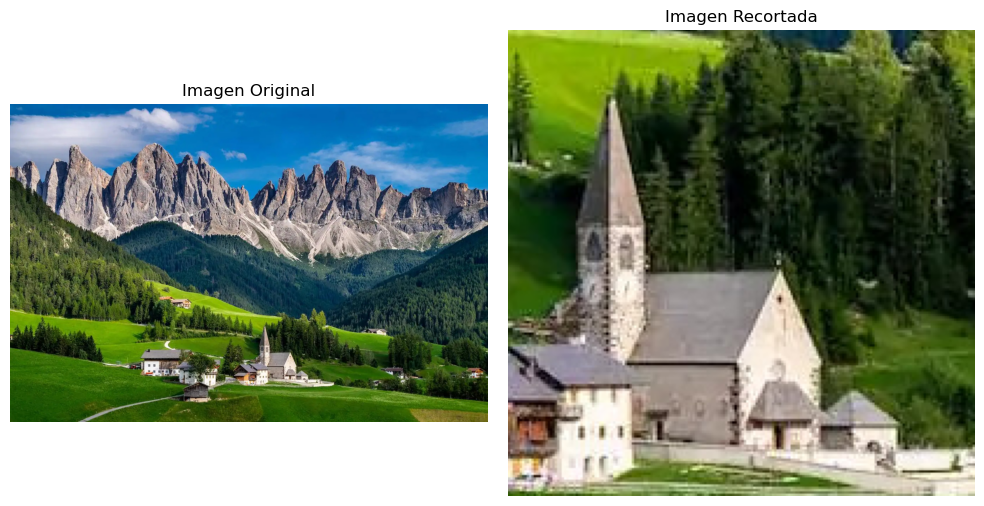

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread("imagen evaluadas/paisaje1.jpg")

alto, ancho = imagen.shape[:2]

lado = 200

desplazamiento_x = 100  
desplazamiento_y =250   

centro_x = ancho // 2 + desplazamiento_x
centro_y = alto // 2 + desplazamiento_y

x1 = max(0, centro_x - lado // 2) 
y1 = max(0, centro_y - lado // 2) 
x2 = min(ancho, centro_x + lado // 2) 
y2 = min(alto, centro_y + lado // 2) 

imagen_recortada = imagen[y1:y2, x1:x2]
#cv2.imwrite("imagen evaluadas/eje1/recorte.jpg", imagen_recortada)

imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
imagen_recortada_rgb = cv2.cvtColor(imagen_recortada, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(imagen_rgb)
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_recortada_rgb)
plt.title("Imagen Recortada")
plt.axis('off')

plt.tight_layout()
plt.show()


Ejercicio 2.
Genera un degradado lineal a colores.

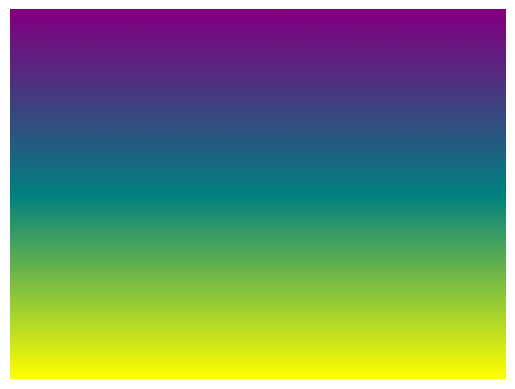

In [313]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
# Definicion de colores
colores = [(0, "purple"),(0.01, "purple"), (0.5, "teal"), (1, "yellow")]  # para generar escala de grices
cmap=LinearSegmentedColormap.from_list('degradado',colores)#listar los colores y generara color map a traves del array
imagen_degradado=cmap(np.linspace(0,1,256).reshape(-1,1))
plt.imshow(imagen_degradado,aspect='auto')
plt.axis('off')
plt.savefig('imagen evaluadas/eje2/imagen_degradada.png', bbox_inches='tight')
plt.show()

Ejercicio 4.
Tomando en cuenta el ejercicio 2 aplica la ecualización del histograma y muestra el
mismo viendo las diferencias entre imágenes e histogramas.

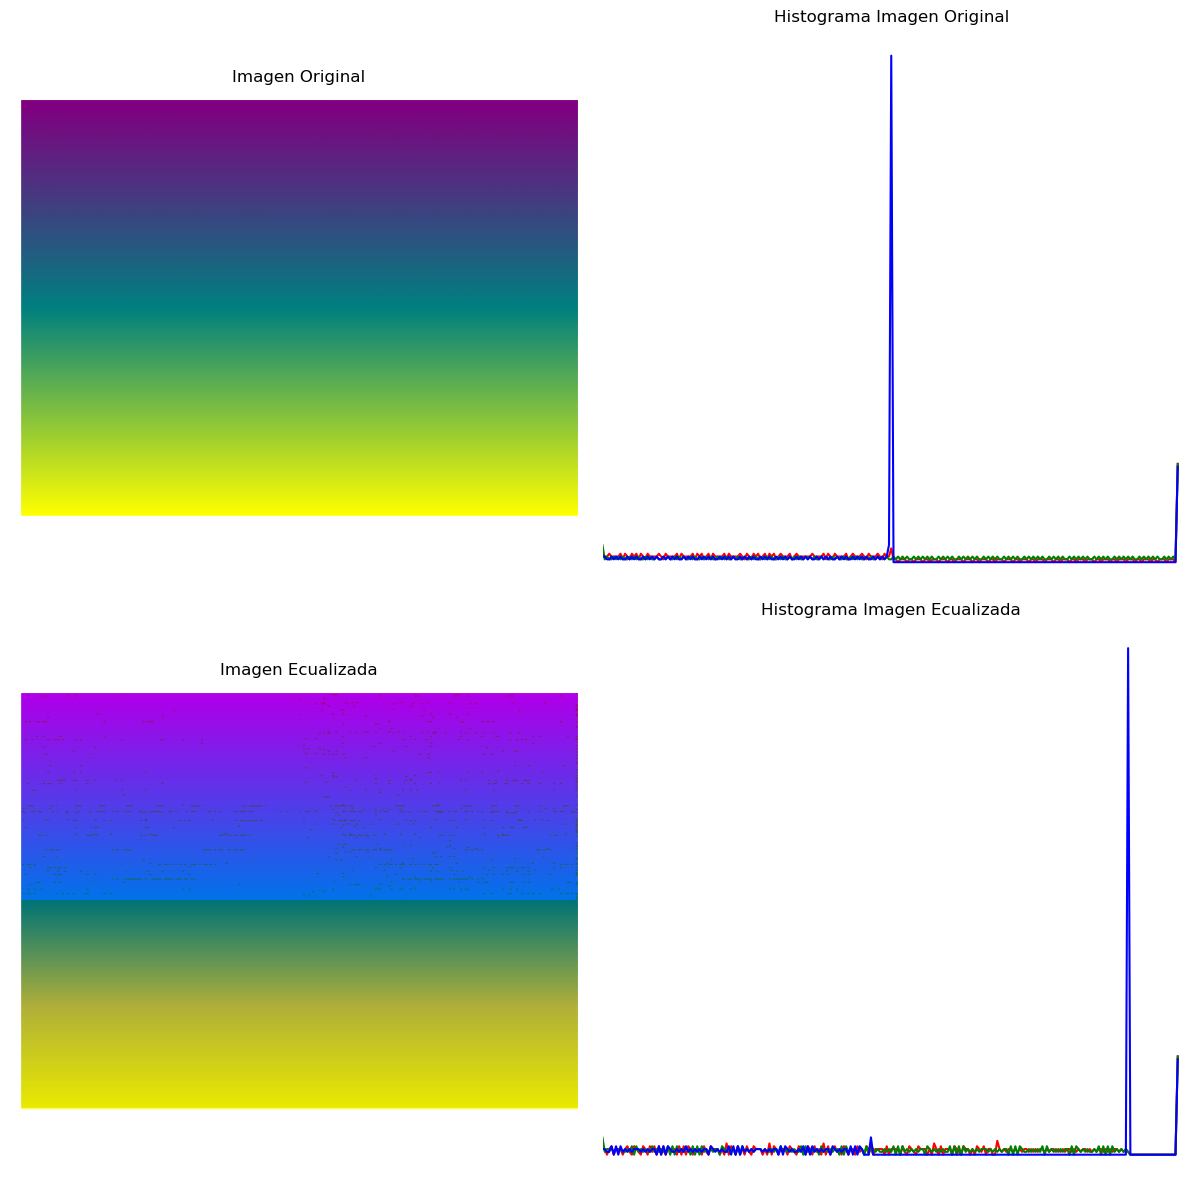

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('imagen evaluadas/eje2/imagen_degradada.png')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

canal_rojo, canal_verde, canal_azul = cv2.split(imagen_rgb)
canal_rojo_ecualizado = cv2.equalizeHist(canal_rojo)
canal_verde_ecualizado = cv2.equalizeHist(canal_verde)
canal_azul_ecualizado = cv2.equalizeHist(canal_azul)
imagen_ecualizada = cv2.merge([canal_rojo_ecualizado, canal_verde_ecualizado, canal_azul_ecualizado])

plt.figure(figsize=(12, 12))

plt.subplot(2, 2, 1)
plt.imshow(imagen_rgb)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(2, 2, 2)
color = ('r', 'g', 'b')
for canal, col in enumerate(color):
    histograma = cv2.calcHist([imagen_rgb], [canal], None, [256], [0, 256])
    plt.plot(histograma, color=col)
plt.title('Histograma Imagen Original')
plt.xlim([0, 256])
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(imagen_ecualizada)
plt.title('Imagen Ecualizada')
plt.axis('off')

plt.subplot(2, 2, 4)
for canal, col in enumerate(color):
    histograma_ecualizado = cv2.calcHist([imagen_ecualizada], [canal], None, [256], [0, 256])
    plt.plot(histograma_ecualizado, color=col)
plt.title('Histograma Imagen Ecualizada')
plt.xlim([0, 256])
plt.axis('off')

plt.tight_layout()
plt.show()


Ejercicio 5.
Tomando en cuenta la imagen1.jpg aplica un degradado lineal en ella.

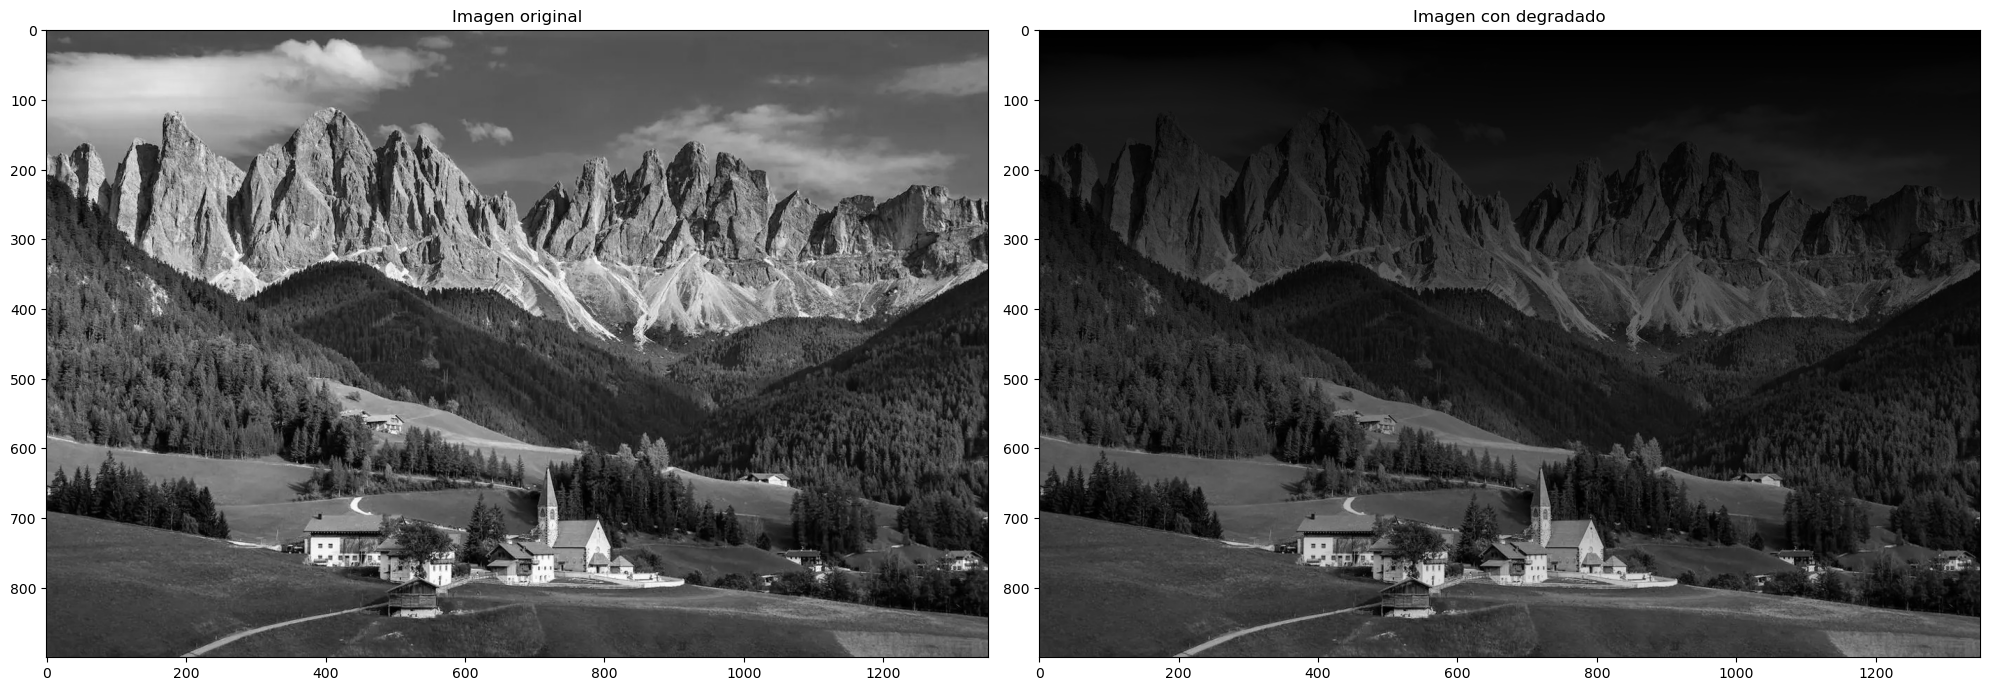

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagen evaluadas/paisaje1.jpg',0)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gradient = np.linspace(0, 1, img.shape[0])[:, np.newaxis]
mask = gradient * np.ones((1, img.shape[1]))

result = img * mask[..., np.newaxis]

plt.figure(figsize=(20, 7))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Imagen original')

plt.subplot(1, 2, 2)
plt.imshow(result.astype(np.uint8))
plt.title('Imagen con degradado')

plt.tight_layout()
plt.show()

